# From Earth to Plate - Notebook 05: The personal playbook

**Maurice Baz & Dominika Bondyra - JH Data Patterns and Representations, final project**

This notebook builds **deck slide 9** (the falling action of the deck): the personal playbook.
After the earlier notebooks establish that food is a major emissions lever and that the gap
between animal- and plant-based foods is enormous, this notebook answers the audience's natural
question: *"OK - what can I actually do?"* It quantifies two levers a single person controls
directly:

1. **Swap savings** - kg CO2e avoided per kg of food swapped, for a curated list of realistic
   swaps -> `figures/fig_slide09_swaps.png`
2. **An annualized example** - what those swaps are worth per person per year, anchored against
   the average American's total carbon footprint -> `figures/fig_slide09_annual_example.png`


## Data

- **`data/Food_Product_Emissions.csv`** - 43 food products, supply-chain GHG emissions in
  kg CO2e per kg of food (Poore & Nemecek 2018, *Science*, as distributed via Our World in Data).
- **`data/ReFED_surplus_table(Surplus Data).csv`** - US food surplus by sector, ReFED 2025
  estimates. Used here only for the residential food-waste GHG figure (100 MMt CO2e).

**Emissions basis (project decision).** All per-kg numbers use the **"Total from Land to
Retail"** column - the land-to-retail total. It covers land-use change through the retail shelf
and is the fair basis for comparing foods as purchased. On this basis beef (beef herd) = 59.57
and peas = 0.896 kg CO2e per kg - the roughly 60:1 contrast used across the deck. The
alternative "Total Global Average" column adds post-retail losses and would give beef 99.5
(~100:1); we footnote it rather than mix bases.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths resolve whether the notebook runs from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# ---- house style (shared across all four notebooks) ----
INK      = '#0b0b0b'   # primary ink (titles)
INK2     = '#52514e'   # secondary ink (subtitles, value labels)
MUTED    = '#898781'   # axis ticks/titles, captions
SURFACE  = '#fcfcfb'   # figure + axes background
GRID     = '#e1e0d9'   # hairline grid
AXISLINE = '#c3c2b7'   # baseline/axis line
BLUE       = '#2a78d6' # sequential default (also semantic: animal-based)
BLUE_EMPH  = '#104281' # sequential emphasized
BLUE_LIGHT = '#9ec5f4' # sequential de-emphasized
GREEN      = '#008300' # semantic: plant-based

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.edgecolor': AXISLINE, 'axes.linewidth': 0.8,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelcolor': MUTED, 'ytick.labelcolor': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
})


In [2]:
per_kg = pd.read_csv(DATA / 'Food_Product_Emissions.csv')
refed  = pd.read_csv(DATA / 'ReFED_surplus_table(Surplus Data).csv').dropna(how='all')
# The GHG header arrives mojibaked from the source export - rename it on load.
refed.columns = ['GHG (MMt CO2e)' if 'GHG' in c else c for c in refed.columns]

BASIS = 'Total from Land to Retail'          # project-wide emissions basis
ltr = per_kg.set_index('Food product')[BASIS]

# Sanity checks: the basis decision reproduces the deck's headline contrast.
assert len(per_kg) == 43 and per_kg.isna().sum().sum() == 0
beef, peas = ltr['Beef (beef herd)'], ltr['Peas']
print(f'Beef (beef herd) land-to-retail: {beef:.2f} kg CO2e/kg')
print(f'Peas land-to-retail:             {peas:.3f} kg CO2e/kg')
print(f'Beef:peas ratio:                 {beef/peas:.1f}:1  (the roughly 60:1 contrast)')
print(f"(Total Global Average column would give beef "
      f"{per_kg.set_index('Food product').loc['Beef (beef herd)', 'Total Global Average GHG Emissions per kg']:.2f} ~ 100:1)")
refed


Beef (beef herd) land-to-retail: 59.57 kg CO2e/kg
Peas land-to-retail:             0.896 kg CO2e/kg
Beef:peas ratio:                 66.5:1  (the roughly 60:1 contrast)
(Total Global Average column would give beef 99.48 ~ 100:1)


,Sector,Surplus (M tons),% of total,GHG (MMt CO2e),Value ($B)
0,Residential,23.50,33.2%,100.00,141.0
1,Farm,16.90,23.9%,3.56,13.4
2,Manufacturing,13.20,18.6%,38.60,42.7
3,Foodservice,12.50,17.7%,63.60,157.0
4,Retail,4.63,6.5%,15.10,30.3


## Analysis A - What one kilogram of swapping is worth

For each swap we subtract the "to" food's land-to-retail intensity from the "from" food's and
report the difference: **kg CO2e avoided per kg of food swapped**. The list is curated to be
realistic (protein for protein, drink for drink): beef to plant proteins, beef to other meats,
then lamb / cheese / dairy-herd beef / shrimp to lighter alternatives, plus two deliberately
modest swaps (milk -> soymilk, pork -> chicken) to show the scale gap *within* the playbook.

Swaps are **mass-for-mass** (1 kg replaced by 1 kg). That is conservative for the beef swaps:
notebook 01's per-protein analysis (beef:peas = 113:1 per 100 g protein, vs ~66:1 per kg here)
shows the ranking holds - and the beef swaps would look even better - under fair protein
accounting.


In [3]:
swap_list = [
    ('Beef (beef herd)',  'Other Pulses',  'Beef -> legumes'),
    ('Beef (beef herd)',  'Tofu',          'Beef -> tofu'),
    ('Beef (beef herd)',  'Fish (farmed)', 'Beef -> fish (farmed)'),
    ('Beef (beef herd)',  'Poultry Meat',  'Beef -> chicken'),
    ('Beef (beef herd)',  'Pig Meat',      'Beef -> pork'),
    ('Lamb & Mutton',     'Poultry Meat',  'Lamb -> chicken'),
    ('Cheese',            'Tofu',          'Cheese -> tofu'),
    ('Beef (dairy herd)', 'Poultry Meat',  'Beef (dairy) -> chicken'),
    ('Shrimps (farmed)',  'Fish (farmed)', 'Shrimp -> fish (farmed)'),
    ('Milk',              'Soymilk',       'Milk -> soymilk'),
    ('Pig Meat',          'Poultry Meat',  'Pork -> chicken'),
]
swaps = pd.DataFrame(
    [{'swap': lbl, 'from': f, 'to': t,
      'from_kgCO2e': ltr[f], 'to_kgCO2e': ltr[t], 'saved_kg_per_kg': ltr[f] - ltr[t]}
     for f, t, lbl in swap_list]
).sort_values('saved_kg_per_kg', ascending=False).reset_index(drop=True)

top = swaps['saved_kg_per_kg'].max()
r_milk = top / swaps.loc[swaps['swap'] == 'Milk -> soymilk',  'saved_kg_per_kg'].iloc[0]
r_pork = top / swaps.loc[swaps['swap'] == 'Pork -> chicken',  'saved_kg_per_kg'].iloc[0]
print(f'Top swap (beef -> legumes): {top:.2f} kg CO2e saved per kg')
print(f'Milk -> soymilk is {r_milk:.0f}x smaller; pork -> chicken is {r_pork:.0f}x smaller')
swaps.round(2)


Top swap (beef -> legumes): 57.96 kg CO2e saved per kg
Milk -> soymilk is 31x smaller; pork -> chicken is 49x smaller


,swap,from,to,from_kgCO2e,to_kgCO2e,saved_kg_per_kg
0,Beef -> legumes,Beef (beef herd),Other Pulses,59.57,1.61,57.96
1,Beef -> tofu,Beef (beef herd),Tofu,59.57,2.87,56.70
2,Beef -> fish (farmed),Beef (beef herd),Fish (farmed),59.57,5.18,54.39
3,Beef -> chicken,Beef (beef herd),Poultry Meat,59.57,6.09,53.48
4,Beef -> pork,Beef (beef herd),Pig Meat,59.57,7.28,52.29
5,Cheese -> tofu,Cheese,Tofu,21.24,2.87,18.37
6,Lamb -> chicken,Lamb & Mutton,Poultry Meat,24.42,6.09,18.32
7,Beef (dairy) -> chicken,Beef (dairy herd),Poultry Meat,21.08,6.09,14.99
8,Shrimp -> fish (farmed),Shrimps (farmed),Fish (farmed),11.85,5.18,6.67
9,Milk -> soymilk,Milk,Soymilk,2.78,0.91,1.87


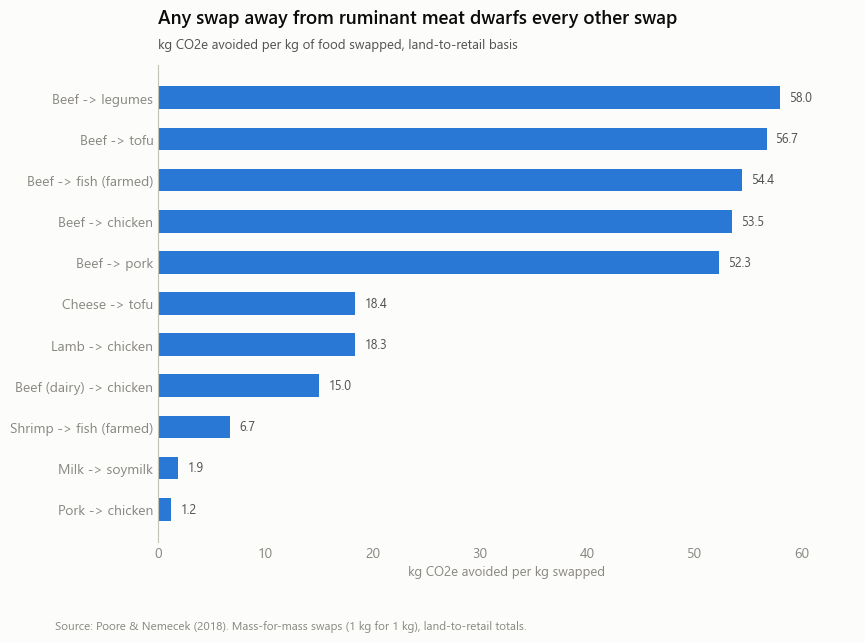

In [4]:
d = swaps.sort_values('saved_kg_per_kg')          # ascending -> largest bar on top
fig, ax = plt.subplots(figsize=(9, 6.2))

ax.barh(d['swap'], d['saved_kg_per_kg'], height=0.55, color=BLUE)   # one measure -> one hue

ax.grid(axis='x')                                  # grid only along the value axis
ax.grid(axis='y', visible=False)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(AXISLINE)              # categorical baseline
ax.tick_params(length=0)
ax.set_xlim(0, 65)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_xlabel('kg CO2e avoided per kg swapped', fontsize=9.5)

for y, v in enumerate(d['saved_kg_per_kg']):       # direct value labels at bar tips
    ax.text(v + 0.9, y, f'{v:,.1f}', va='center', fontsize=9, color=INK2)

ax.set_title('Any swap away from ruminant meat dwarfs every other swap',
             loc='left', fontsize=13.5, fontweight=600, color=INK, pad=30)
ax.text(0, 1.035, 'kg CO2e avoided per kg of food swapped, land-to-retail basis',
        transform=ax.transAxes, fontsize=9.5, color=INK2)
fig.text(0.01, -0.03,
         'Source: Poore & Nemecek (2018). Mass-for-mass swaps (1 kg for 1 kg), '
         'land-to-retail totals.',
         fontsize=8.5, color=MUTED)

fig.savefig(FIGS / 'fig_slide09_swaps.png')
plt.show()


**Takeaway.** Any swap away from ruminant meat dwarfs every other swap in the playbook.
Replacing beef (beef herd) saves **57.96 kg CO2e per kg** when going to legumes, 56.7 to tofu,
54.4 to farmed fish, 53.5 to chicken - and even staying with meat, **beef -> pork still saves
~52.3 kg per kg**. The middle tier (cheese -> tofu 18.4, lamb -> chicken 18.3, dairy-herd
beef -> chicken 15.0) is roughly a third of that. The everyday-sounding swaps - milk -> soymilk
(1.87) and pork -> chicken (1.19) - are **31x and 49x smaller** than beef -> legumes. The lever
that matters is the ruminant lever; everything else is rounding error by comparison.


## Analysis B - Making it personal: one American, one year

Per-kg numbers are abstract; annual tonnes are not. We annualize at the **US-average beef
consumption of 26.35 kg per person per year** (58.1 lb, retail weight; USDA Economic Research
Service, 2023 actual - 2024 estimated unchanged) and compare three actions one person controls:

1. Swap all beef for legumes for a year (26.35 kg x 57.96 kg CO2e/kg).
2. Swap all beef for chicken for a year (26.35 kg x 53.48 kg CO2e/kg).
3. Cut household food waste to zero: ReFED 2025 estimates put US **residential** food-waste
   GHG at 100 MMt CO2e/yr; divided by the US population of 340.1 million (U.S. Census Bureau,
   Vintage 2024 Population Estimates, July 1, 2024) that is ~0.29 t per person per year.

The context anchor is the average American's total footprint of **17.53 t CO2e/yr** (Jones et
al. 2025, *Scientific Data*, via Our World in Data - per-capita GHG emissions incl. land use,
2024); the global average is 6.67 t.

In [5]:
# Verified external constants (full citations in the Sources cell)
BEEF_KG_PER_YR = 26.35       # kg = 58.1 lb retail weight, 2023 actual (USDA ERS; 2024 est. unchanged)
US_POP_M       = 340.1       # millions, July 1 2024 (US Census Bureau, Vintage 2024 Population Estimates)
US_FOOTPRINT_T = 17.53       # t CO2e/person/yr, US 2024 incl. land use (Jones et al. 2025 via Our World in Data)
GLOBAL_FOOT_T  = 6.67        # t CO2e/person/yr, world 2024, same series

save_legumes_t = (ltr['Beef (beef herd)'] - ltr['Other Pulses']) * BEEF_KG_PER_YR / 1000
save_chicken_t = (ltr['Beef (beef herd)'] - ltr['Poultry Meat']) * BEEF_KG_PER_YR / 1000
res_ghg_mmt    = refed.loc[refed['Sector'] == 'Residential', 'GHG (MMt CO2e)'].iloc[0]
save_waste_t   = res_ghg_mmt * 1e6 / (US_POP_M * 1e6)     # MMt -> t, per person

pct_us     = save_chicken_t / US_FOOTPRINT_T * 100
pct_global = save_chicken_t / GLOBAL_FOOT_T * 100

print(f'Beef -> legumes for a year: {save_legumes_t:.2f} t CO2e avoided')
print(f'Beef -> chicken for a year: {save_chicken_t:.2f} t CO2e avoided')
print(f'Household food waste to zero: {save_waste_t:.2f} t CO2e avoided '
      f'({res_ghg_mmt:.0f} MMt residential / {US_POP_M:.1f}M people)')
print(f'Beef -> chicken alone = {pct_us:.1f}% of the average US footprint ({US_FOOTPRINT_T} t)')
print(f'                      = {pct_global:.1f}% of the global average footprint ({GLOBAL_FOOT_T} t)')


Beef -> legumes for a year: 1.53 t CO2e avoided
Beef -> chicken for a year: 1.41 t CO2e avoided
Household food waste to zero: 0.29 t CO2e avoided (100 MMt residential / 340.1M people)
Beef -> chicken alone = 8.0% of the average US footprint (17.53 t)
                      = 21.1% of the global average footprint (6.67 t)


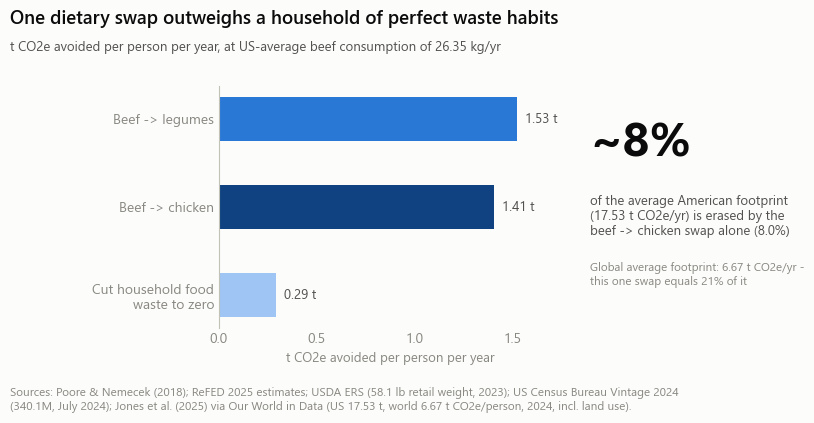

In [6]:
labels = ['Cut household food\nwaste to zero', 'Beef -> chicken', 'Beef -> legumes']
values = [save_waste_t, save_chicken_t, save_legumes_t]
colors = [BLUE_LIGHT, BLUE_EMPH, BLUE]     # one hue family: default / emphasized / de-emphasized

fig, ax = plt.subplots(figsize=(9.5, 3.9))
fig.subplots_adjust(left=0.24, right=0.60, top=0.78, bottom=0.16)

ax.barh(labels, values, height=0.5, color=colors)
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(AXISLINE)
ax.tick_params(length=0)
ax.set_xlim(0, 1.75)
ax.set_xticks([0, 0.5, 1.0, 1.5])
ax.set_xlabel('t CO2e avoided per person per year', fontsize=9.5)

for y, v in enumerate(values):
    ax.text(v + 0.04, y, f'{v:.2f} t', va='center', fontsize=9.5, color=INK2)

# stat tile on the right - text wears ink, never a series color
fig.text(0.63, 0.60, f'~{pct_us:.0f}%', fontsize=34, fontweight=700, color=INK)
fig.text(0.63, 0.40,
         f'of the average American footprint\n({US_FOOTPRINT_T} t CO2e/yr) is erased by the\n'
         f'beef -> chicken swap alone ({pct_us:.1f}%)',
         fontsize=9.5, color=INK2)
fig.text(0.63, 0.27,
         f'Global average footprint: {GLOBAL_FOOT_T} t CO2e/yr -\n'
         f'this one swap equals {pct_global:.0f}% of it',
         fontsize=8.5, color=MUTED)

fig.text(0.02, 0.94, 'One dietary swap outweighs a household of perfect waste habits',
         fontsize=13.5, fontweight=600, color=INK)
fig.text(0.02, 0.87,
         't CO2e avoided per person per year, at US-average beef consumption of 26.35 kg/yr',
         fontsize=9.5, color=INK2)
fig.text(0.02, -0.05,
         'Sources: Poore & Nemecek (2018); ReFED 2025 estimates; USDA ERS (58.1 lb retail '
         'weight, 2023); US Census Bureau Vintage 2024\n(340.1M, July 2024); Jones et al. (2025) '
         'via Our World in Data (US 17.53 t, world 6.67 t CO2e/person, 2024, incl. land use).',
         fontsize=8.5, color=MUTED)

fig.savefig(FIGS / 'fig_slide09_annual_example.png')
plt.show()


**Takeaway.** At average US beef consumption, **beef -> legumes avoids ~1.53 t CO2e per year**
and **beef -> chicken ~1.41 t** - the beef -> chicken swap alone erases **~8.0% (~8%)** of the
average American's 17.53 t annual footprint, and equals **~21%** of the entire global average
footprint (6.67 t). By contrast, cutting household food waste to zero - a genuinely good habit -
is worth **~0.29 t/yr**, about a fifth of either beef swap. The playbook's headline is one
sentence: *change what is on the plate before optimizing what falls off it.*

## Assumptions table

| # | Assumption | Value used | Basis / source | Status |
|---|------------|------------|----------------|--------|
| 1 | US per-capita beef consumption | 26.35 kg/person/yr (58.1 lb, retail weight, 2023 actual; 2024 estimated unchanged) | USDA Economic Research Service, per-capita beef consumption (retail weight) | Source-verified |
| 2 | Emissions basis | "Total from Land to Retail" (land-to-retail total), kg CO2e per kg food | Poore & Nemecek (2018); project-wide basis decision | Fixed by project |
| 3 | Residential food-waste GHG | 100 MMt CO2e/yr (US residential sector) | ReFED 2025 estimates | As published |
| 4 | US population | 340.1 million (July 1, 2024) | U.S. Census Bureau, Vintage 2024 Population Estimates | Source-verified |
| 5 | Household-waste saving | 100 MMt / 340.1M people = 0.29 t CO2e/person/yr | Derived from rows 3-4; assumes residential waste emissions scale per capita | Derived |
| 6 | US per-capita GHG footprint | 17.53 t CO2e/yr (2024, incl. land use; CO2+CH4+N2O, IPCC AR6 GWP100) | Jones et al. (2025), *Scientific Data* - via Our World in Data | Source-verified |
| 7 | Global per-capita GHG footprint | 6.67 t CO2e/yr (2024) | Same series (Jones et al. 2025 via Our World in Data) | Source-verified |
| 8 | Swap accounting | Mass-for-mass: 1 kg of the "from" food replaced by 1 kg of the "to" food | Simplicity and transparency | Conservative - see note |

**Note on retail weight (row 1).** The 58.1 lb (26.35 kg) figure is retail weight, which
includes some bone and trim, so it slightly overstates bone-free intake relative to Poore &
Nemecek's per-kg functional unit - we use the standard retail-weight figure knowingly.

**Note on mass-for-mass (row 8).** Swapping 1 kg of beef for 1 kg of legumes is not calorie- or
protein-identical. But notebook 01's per-protein analysis shows **beef:peas = 113:1 per 100 g of
protein** (vs ~66:1 per kg on the land-to-retail basis), so fair protein accounting does not
rescue beef - protein-adjusting would make the beef swaps look even **better**, not worse. The
mass-for-mass numbers reported here are conservative for the story being told.

**Footnote on the basis column.** On the "Total Global Average GHG Emissions per kg" column
(which adds post-retail losses), beef (beef herd) is 99.48 kg CO2e/kg (~100:1 vs peas) and every
beef-swap saving above would be roughly two-thirds larger. We stay on land-to-retail for
consistency across the deck.

## Limitations

- **Global averages hide variance.** Poore & Nemecek pool ~38,000 farms; individual producers
  vary widely. The ranking is robust (even low-impact beef exceeds most plant proteins), but any
  single household's exact savings will differ.
- **Mass-for-mass swaps are not nutritionally identical.** See the assumptions note: the
  per-protein basis (113:1) makes the beef swaps look better, not worse, so the conclusion holds.
- **The 0.29 t waste figure is an even per-capita split** of a sector-level ReFED estimate;
  actual household waste varies a lot, and reaching literal zero is aspirational.
- **Mixed frames.** ReFED's figure is a US, full-supply-chain estimate for wasted food; Poore &
  Nemecek intensities are global land-to-retail averages. The two serve as contextual anchors in
  one chart, not as a strictly comparable series.
- **Land-to-retail excludes post-retail losses**, so consumer-level savings would be larger for
  every animal product (beef 99.5 on the total-average column).


## Sources

- Poore, J. & Nemecek, T. (2018). "Reducing food's environmental impacts through producers and
  consumers." *Science* 360(6392), 987-992. Data as distributed via Our World in Data
  (`data/Food_Product_Emissions.csv`, `data/ghg-per-protein-poore.csv`).
- ReFED (2025). US food surplus and waste estimates - "ReFED 2025 estimates"
  (`data/ReFED_surplus_table(Surplus Data).csv`).
- USDA Economic Research Service, per-capita beef consumption (retail weight): 58.1 lb
  (26.35 kg) per person, 2023 (2024 estimated unchanged).
- U.S. Census Bureau, Vintage 2024 Population Estimates: 340.1 million (July 1, 2024).
- Jones et al. (2025), "National contributions to climate change," *Scientific Data* - via Our
  World in Data: per-capita GHG emissions including land use (CO2+CH4+N2O, IPCC AR6 GWP100),
  United States 2024 = 17.53 t, World 2024 = 6.67 t CO2e per person per year.